# Week 4-5 -- Feature Selection dan Dimensionality Reduction
## Prediksi State of Charge (SOC) Baterai Kendaraan Listrik
**Mata Kuliah:** Proyek Data Mining

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, glob, warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import mutual_info_classif, f_classif, RFE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

BASE_DIR = r'd:\Tugas Kuliah\SEM 6\Proyek Data Mining\Battery'
DATA_DIR = os.path.join(BASE_DIR, 'Data')
NOMINAL_CAPACITY = 3.0

## 1. Load Data dan Feature Engineering

In [2]:
def find_header_row(filepath):
    with open(filepath, 'r', errors='ignore') as f:
        for i, line in enumerate(f):
            if line.strip().startswith('Time Stamp,Step,Status'):
                return i
    return None

def load_csv(filepath):
    hr = find_header_row(filepath)
    if hr is None: return None
    df = pd.read_csv(filepath, skiprows=list(range(hr)) + [hr+1])
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    df.columns = df.columns.str.strip()
    return df

RELEVANT = ['UDDS','HWFET','LA92','US06','Mixed1','Mixed2','Mixed3','Mixed4',
            'Mixed5','Mixed6','Mixed7','Mixed8','Dis_0p5C','Dis_2C','Cap_1C']
EXCLUDE = ['Charge','HPPC','PausCycl','C20DisCh']
temp_folders = ['n20degC','n10degC','0degC','10degC','25degC','40degC']
temp_map = {'n20degC':'-20','n10degC':'-10','0degC':'0','10degC':'10','25degC':'25','40degC':'40'}

all_dfs = []
for folder in temp_folders:
    path = os.path.join(DATA_DIR, folder)
    for fpath in sorted(glob.glob(os.path.join(path, '*.csv'))):
        fname = os.path.basename(fpath)
        if not any(p in fname for p in RELEVANT) or any(p in fname for p in EXCLUDE):
            continue
        df_t = load_csv(fpath)
        if df_t is None or len(df_t) == 0: continue
        df_t['Ambient_Temp'] = float(temp_map[folder])
        all_dfs.append(df_t)

df_all = pd.concat(all_dfs, ignore_index=True)
print(f"Total baris: {len(df_all):,}, Kolom: {df_all.shape[1]}")

Total baris: 4,504,880, Kolom: 15


In [3]:
# Hitung SOC
df_all['SOC'] = (1 - (df_all['Capacity'].abs() / NOMINAL_CAPACITY)) * 100
df_all['SOC'] = df_all['SOC'].clip(0, 100)

# Feature Engineering
df_all['Power'] = df_all['Voltage'] * df_all['Current']
df_all['dV'] = df_all['Voltage'].diff().fillna(0)
df_all['dI'] = df_all['Current'].diff().fillna(0)
df_all['dT'] = df_all['Temperature'].diff().fillna(0)
df_all['V_roll_mean'] = df_all['Voltage'].rolling(10, min_periods=1).mean()
df_all['I_roll_mean'] = df_all['Current'].rolling(10, min_periods=1).mean()
df_all['V_roll_std'] = df_all['Voltage'].rolling(10, min_periods=1).std().fillna(0)
df_all['I_roll_std'] = df_all['Current'].rolling(10, min_periods=1).std().fillna(0)
df_all['V_I_ratio'] = df_all['Voltage'] / (df_all['Current'].abs() + 0.001)

# Binning SOC menjadi kelas klasifikasi
bins = [0, 20, 40, 60, 80, 100]
labels_soc = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
df_all['SOC_class'] = pd.cut(df_all['SOC'], bins=bins, labels=labels_soc, include_lowest=True)
df_all = df_all.dropna(subset=['SOC_class'])

print(f"\nDistribusi kelas SOC:")
print(df_all['SOC_class'].value_counts().sort_index())


Distribusi kelas SOC:
SOC_class
Very Low      204936
Low           850435
Medium       1179019
High         1042637
Very High    1227850
Name: count, dtype: int64


In [4]:
# Subsample untuk efisiensi komputasi
np.random.seed(42)
df_sample = df_all.sample(n=min(80000, len(df_all)), random_state=42).reset_index(drop=True)

feature_names = ['Voltage','Current','Temperature','Ambient_Temp',
                 'Power','dV','dI','dT','V_roll_mean','I_roll_mean','V_roll_std','I_roll_std','V_I_ratio']
# Catatan: Capacity dan WhAccu tidak dimasukkan sebagai fitur karena SOC dihitung langsung
# dari Capacity (SOC = 1 - |Capacity|/3.0). Memasukkannya akan menyebabkan data leakage.

X = df_sample[feature_names].values
le = LabelEncoder()
y = le.fit_transform(df_sample['SOC_class'])
class_names = le.classes_

print(f"Fitur ({len(feature_names)}): {feature_names}")
print(f"Kelas: {list(class_names)}")
print(f"Shape X: {X.shape}, y: {y.shape}")

Fitur (13): ['Voltage', 'Current', 'Temperature', 'Ambient_Temp', 'Power', 'dV', 'dI', 'dT', 'V_roll_mean', 'I_roll_mean', 'V_roll_std', 'I_roll_std', 'V_I_ratio']
Kelas: ['High', 'Low', 'Medium', 'Very High', 'Very Low']
Shape X: (80000, 13), y: (80000,)


In [5]:
# Split dan Standardisasi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (64000, 13), Test: (16000, 13)


---
## 2. Skenario 1 -- Baseline Model (Tanpa Feature Selection)
Kami membangun model menggunakan seluruh 13 fitur tanpa seleksi atau reduksi dimensi.


Model: Baseline Random Forest
Akurasi: 0.9319
              precision    recall  f1-score   support

        High       0.91      0.91      0.91      3725
         Low       0.92      0.95      0.94      2999
      Medium       0.92      0.91      0.92      4142
   Very High       0.97      0.96      0.96      4394
    Very Low       0.98      0.94      0.96       740

    accuracy                           0.93     16000
   macro avg       0.94      0.93      0.94     16000
weighted avg       0.93      0.93      0.93     16000



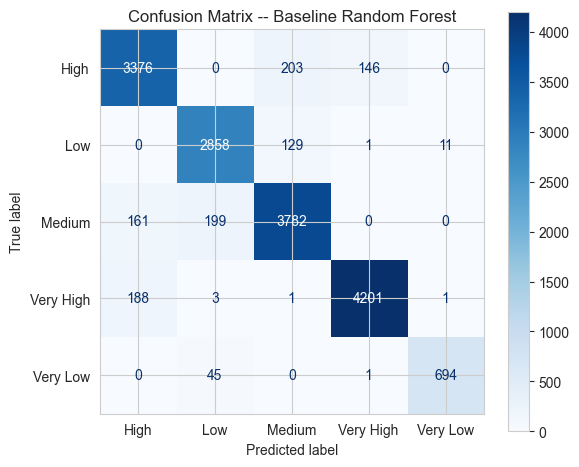


Model: Baseline XGBoost
Akurasi: 0.9383
              precision    recall  f1-score   support

        High       0.92      0.91      0.91      3725
         Low       0.93      0.95      0.94      2999
      Medium       0.92      0.92      0.92      4142
   Very High       0.97      0.97      0.97      4394
    Very Low       0.98      0.95      0.97       740

    accuracy                           0.94     16000
   macro avg       0.94      0.94      0.94     16000
weighted avg       0.94      0.94      0.94     16000



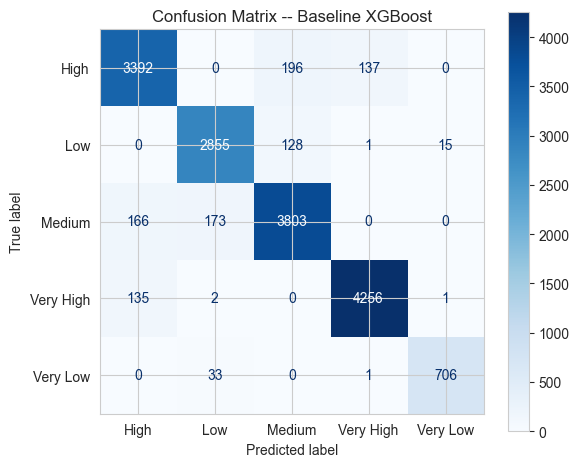

In [6]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name, class_names):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"Akurasi: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_te, y_pred, target_names=class_names))
    fig, ax = plt.subplots(figsize=(6,5))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, display_labels=class_names, ax=ax, cmap='Blues')
    ax.set_title(f'Confusion Matrix -- {name}')
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, 'images', 'week45', f'fig_cm_{name.lower().replace(" ","_")}.png'), dpi=120, bbox_inches='tight')
    plt.show()
    return acc, y_pred

results = {}

# Model 1: Random Forest
acc_rf, _ = evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                           X_train_sc, X_test_sc, y_train, y_test, 'Baseline Random Forest', class_names)
results['Baseline RF'] = acc_rf

# Model 2: XGBoost
acc_xgb, _ = evaluate_model(XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False,
                                           eval_metric='mlogloss', verbosity=0),
                            X_train_sc, X_test_sc, y_train, y_test, 'Baseline XGBoost', class_names)
results['Baseline XGB'] = acc_xgb

---
## 3. Skenario 2 -- Filter Method
Kami menerapkan seleksi fitur menggunakan metode statistik: ANOVA F-test dan Mutual Information.

In [7]:
# ANOVA F-test
f_scores, f_pvalues = f_classif(X_train_sc, y_train)
# Mutual Information
mi_scores = mutual_info_classif(X_train_sc, y_train, random_state=42)

ranking = pd.DataFrame({
    'Fitur': feature_names,
    'ANOVA_F': f_scores.round(2),
    'ANOVA_pval': f_pvalues,
    'Mutual_Info': mi_scores.round(4)
}).sort_values('Mutual_Info', ascending=False)

print("Ranking Fitur (diurutkan berdasarkan Mutual Information):")
print(ranking.to_string(index=False))

Ranking Fitur (diurutkan berdasarkan Mutual Information):
       Fitur  ANOVA_F    ANOVA_pval  Mutual_Info
     Voltage 27848.38  0.000000e+00       0.7222
 V_roll_mean 28132.61  0.000000e+00       0.7048
   V_I_ratio  4631.44  0.000000e+00       0.3206
     Current    94.83  1.432499e-80       0.2019
 I_roll_mean   100.30  2.848040e-85       0.1955
 Temperature   829.12  0.000000e+00       0.1897
       Power   129.12 5.141092e-110       0.1385
  V_roll_std   211.75 8.010627e-181       0.1337
  I_roll_std    93.84  9.979833e-80       0.0847
Ambient_Temp   751.24  0.000000e+00       0.0615
          dV     0.27  8.964685e-01       0.0231
          dI     0.53  7.160225e-01       0.0170
          dT     1.17  3.222265e-01       0.0008


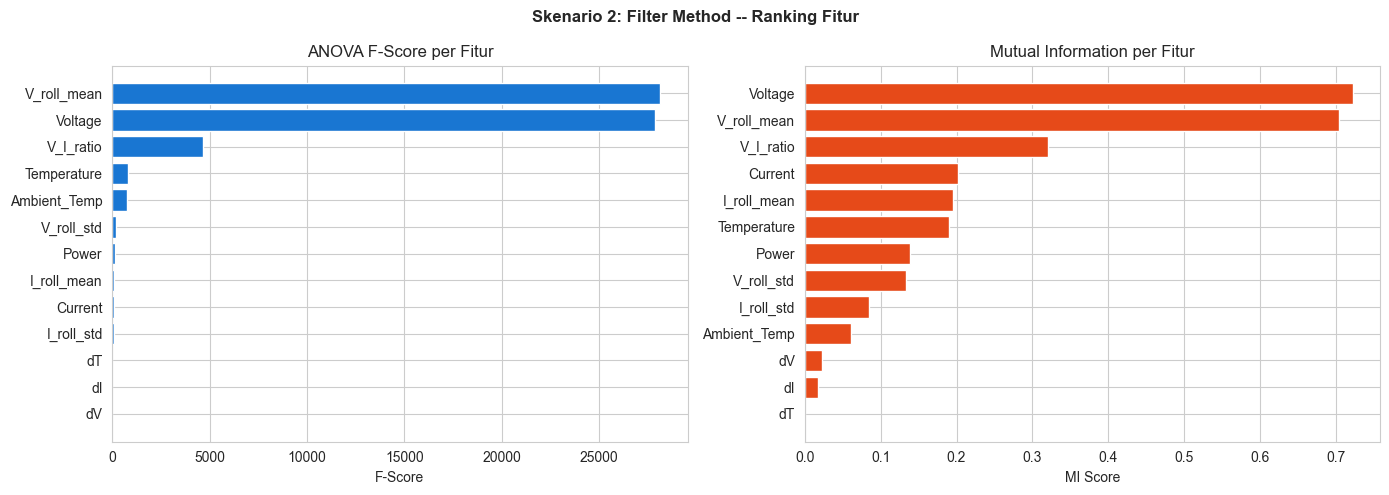

In [8]:
# Visualisasi ranking
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
r = ranking.sort_values('ANOVA_F', ascending=True)
axes[0].barh(r['Fitur'], r['ANOVA_F'], color='#1976D2')
axes[0].set_title('ANOVA F-Score per Fitur')
axes[0].set_xlabel('F-Score')

r2 = ranking.sort_values('Mutual_Info', ascending=True)
axes[1].barh(r2['Fitur'], r2['Mutual_Info'], color='#E64A19')
axes[1].set_title('Mutual Information per Fitur')
axes[1].set_xlabel('MI Score')

plt.suptitle('Skenario 2: Filter Method -- Ranking Fitur', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'images/week45', 'fig_filter_ranking.png'), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Pilih top-K fitur berdasarkan Mutual Information
K = 8
top_features_filter = ranking.head(K)['Fitur'].tolist()
print(f"\nTop {K} fitur terpilih (Filter Method):")
for i, f in enumerate(top_features_filter, 1):
    mi = ranking[ranking['Fitur']==f]['Mutual_Info'].values[0]
    print(f"  {i}. {f} (MI={mi:.4f})")

idx_filter = [feature_names.index(f) for f in top_features_filter]
X_train_filter = X_train_sc[:, idx_filter]
X_test_filter = X_test_sc[:, idx_filter]


Top 8 fitur terpilih (Filter Method):
  1. Voltage (MI=0.7222)
  2. V_roll_mean (MI=0.7048)
  3. V_I_ratio (MI=0.3206)
  4. Current (MI=0.2019)
  5. I_roll_mean (MI=0.1955)
  6. Temperature (MI=0.1897)
  7. Power (MI=0.1385)
  8. V_roll_std (MI=0.1337)



Model: Filter RF
Akurasi: 0.9269
              precision    recall  f1-score   support

        High       0.91      0.90      0.90      3725
         Low       0.91      0.94      0.93      2999
      Medium       0.91      0.91      0.91      4142
   Very High       0.96      0.96      0.96      4394
    Very Low       0.97      0.93      0.95       740

    accuracy                           0.93     16000
   macro avg       0.93      0.93      0.93     16000
weighted avg       0.93      0.93      0.93     16000



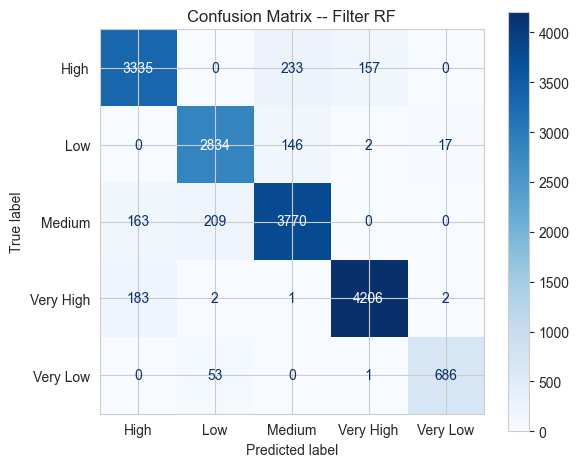


Model: Filter XGBoost
Akurasi: 0.9334
              precision    recall  f1-score   support

        High       0.91      0.90      0.91      3725
         Low       0.93      0.95      0.94      2999
      Medium       0.92      0.91      0.92      4142
   Very High       0.97      0.96      0.96      4394
    Very Low       0.97      0.94      0.96       740

    accuracy                           0.93     16000
   macro avg       0.94      0.93      0.94     16000
weighted avg       0.93      0.93      0.93     16000



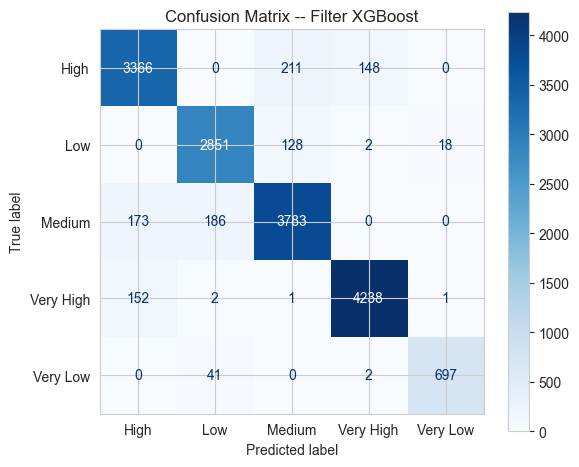

In [10]:
acc_rf_f, _ = evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                              X_train_filter, X_test_filter, y_train, y_test,
                              'Filter RF', class_names)
results['Filter RF'] = acc_rf_f

acc_xgb_f, _ = evaluate_model(XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False,
                                             eval_metric='mlogloss', verbosity=0),
                               X_train_filter, X_test_filter, y_train, y_test,
                               'Filter XGBoost', class_names)
results['Filter XGB'] = acc_xgb_f

**Analisis Filter Method:**
- Fitur terpilih berdasarkan skor Mutual Information tertinggi, yang mengukur dependensi
  non-linear antara fitur dan kelas target.
- ANOVA F-test menguji perbedaan mean antar kelas, cocok untuk fitur dengan hubungan linear.
- Fitur seperti Voltage, V_roll_mean, dan Power memiliki skor tinggi karena memang berkorelasi
  kuat dengan level SOC baterai kendaraan listrik.

---
## 4. Skenario 3 -- Wrapper Method (RFE)
Kami menerapkan Recursive Feature Elimination dengan Random Forest sebagai estimator.

In [11]:
from sklearn.feature_selection import RFE

# RFE dengan Random Forest, pilih 8 fitur
rfe = RFE(estimator=RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
          n_features_to_select=8, step=1)
rfe.fit(X_train_sc, y_train)

rfe_ranking = pd.DataFrame({
    'Fitur': feature_names,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')

print("Hasil RFE -- Ranking Fitur:")
print(rfe_ranking.to_string(index=False))

selected_wrapper = rfe_ranking[rfe_ranking['Selected']]['Fitur'].tolist()
print(f"\nFitur terpilih ({len(selected_wrapper)}): {selected_wrapper}")

Hasil RFE -- Ranking Fitur:
       Fitur  Selected  Ranking
     Voltage      True        1
     Current      True        1
 Temperature      True        1
Ambient_Temp      True        1
       Power      True        1
   V_I_ratio      True        1
 I_roll_mean      True        1
 V_roll_mean      True        1
  V_roll_std     False        2
  I_roll_std     False        3
          dV     False        4
          dI     False        5
          dT     False        6

Fitur terpilih (8): ['Voltage', 'Current', 'Temperature', 'Ambient_Temp', 'Power', 'V_I_ratio', 'I_roll_mean', 'V_roll_mean']



Model: Wrapper RF
Akurasi: 0.9316
              precision    recall  f1-score   support

        High       0.91      0.90      0.90      3725
         Low       0.92      0.95      0.94      2999
      Medium       0.92      0.91      0.91      4142
   Very High       0.96      0.96      0.96      4394
    Very Low       0.98      0.94      0.96       740

    accuracy                           0.93     16000
   macro avg       0.94      0.93      0.94     16000
weighted avg       0.93      0.93      0.93     16000



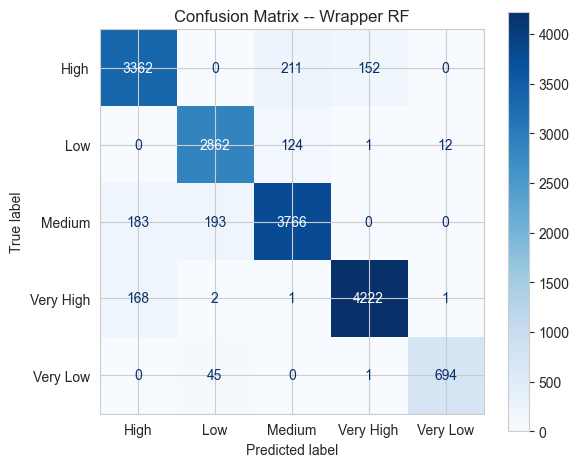


Model: Wrapper XGBoost
Akurasi: 0.9327
              precision    recall  f1-score   support

        High       0.91      0.91      0.91      3725
         Low       0.93      0.95      0.94      2999
      Medium       0.92      0.91      0.91      4142
   Very High       0.97      0.96      0.96      4394
    Very Low       0.97      0.95      0.96       740

    accuracy                           0.93     16000
   macro avg       0.94      0.94      0.94     16000
weighted avg       0.93      0.93      0.93     16000



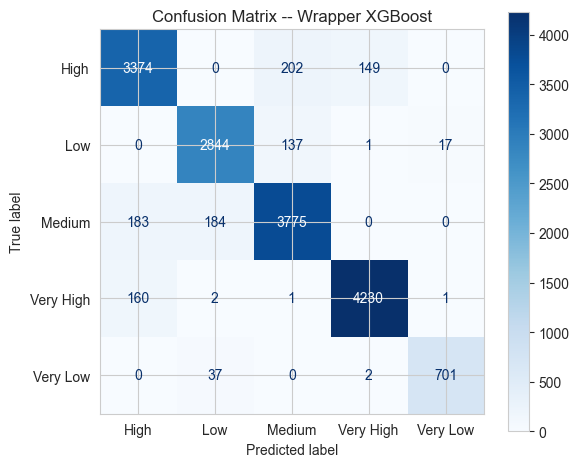

In [12]:
X_train_wrap = rfe.transform(X_train_sc)
X_test_wrap = rfe.transform(X_test_sc)

acc_rf_w, _ = evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                              X_train_wrap, X_test_wrap, y_train, y_test,
                              'Wrapper RF', class_names)
results['Wrapper RF'] = acc_rf_w

acc_xgb_w, _ = evaluate_model(XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False,
                                             eval_metric='mlogloss', verbosity=0),
                               X_train_wrap, X_test_wrap, y_train, y_test,
                               'Wrapper XGBoost', class_names)
results['Wrapper XGB'] = acc_xgb_w

**Analisis Wrapper Method:**
- RFE secara iteratif menghapus fitur yang paling tidak penting berdasarkan feature importance
  dari model Random Forest, hingga tersisa 8 fitur.
- Kelebihan: mempertimbangkan interaksi antar fitur karena menggunakan model aktual.
- Kekurangan: komputasi lebih berat dibanding filter method karena harus training model berulang kali.
- Fitur yang tereliminasi umumnya memiliki redundansi dengan fitur lain yang terpilih.

---
## 5. Skenario 4 -- Embedded Method
Kami mengekstrak feature importance dari Random Forest dan XGBoost.

In [13]:
# Random Forest Feature Importance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_sc, y_train)
rf_importance = rf_model.feature_importances_

# XGBoost Feature Importance
xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False,
                           eval_metric='mlogloss', verbosity=0)
xgb_model.fit(X_train_sc, y_train)
xgb_importance = xgb_model.feature_importances_

imp_df = pd.DataFrame({
    'Fitur': feature_names,
    'RF_Importance': rf_importance,
    'XGB_Importance': xgb_importance,
    'Avg_Importance': (rf_importance + xgb_importance) / 2
}).sort_values('Avg_Importance', ascending=False)

print("Feature Importance (Embedded Method):")
print(imp_df.round(4).to_string(index=False))

Feature Importance (Embedded Method):
       Fitur  RF_Importance  XGB_Importance  Avg_Importance
     Voltage         0.2889          0.1615          0.2252
 V_roll_mean         0.2527          0.1939          0.2233
Ambient_Temp         0.0635          0.3501          0.2068
 Temperature         0.0937          0.0737          0.0837
 I_roll_mean         0.0589          0.0774          0.0681
       Power         0.0541          0.0483          0.0512
   V_I_ratio         0.0597          0.0292          0.0444
     Current         0.0448          0.0232          0.0340
  V_roll_std         0.0278          0.0130          0.0204
  I_roll_std         0.0249          0.0074          0.0161
          dV         0.0198          0.0085          0.0142
          dI         0.0106          0.0058          0.0082
          dT         0.0007          0.0079          0.0043


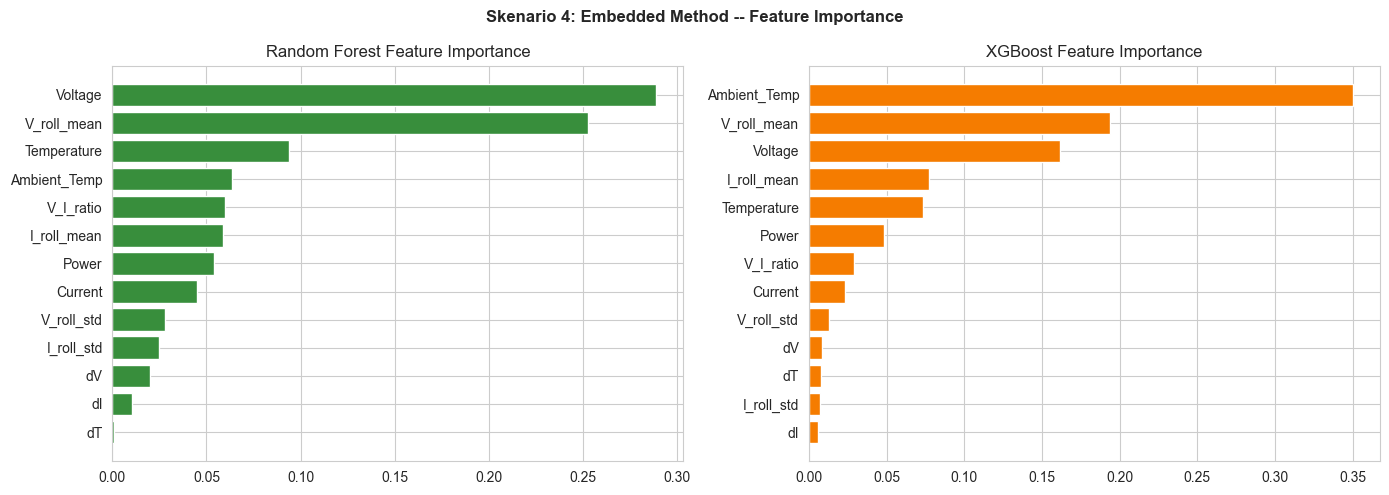

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
imp_rf = imp_df.sort_values('RF_Importance', ascending=True)
axes[0].barh(imp_rf['Fitur'], imp_rf['RF_Importance'], color='#388E3C')
axes[0].set_title('Random Forest Feature Importance')

imp_xgb = imp_df.sort_values('XGB_Importance', ascending=True)
axes[1].barh(imp_xgb['Fitur'], imp_xgb['XGB_Importance'], color='#F57C00')
axes[1].set_title('XGBoost Feature Importance')

plt.suptitle('Skenario 4: Embedded Method -- Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'images/week45', 'fig_embedded_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

Top 8 fitur (Embedded): ['Voltage', 'V_roll_mean', 'Ambient_Temp', 'Temperature', 'I_roll_mean', 'Power', 'V_I_ratio', 'Current']



Model: Embedded RF
Akurasi: 0.9307
              precision    recall  f1-score   support

        High       0.90      0.90      0.90      3725
         Low       0.92      0.95      0.94      2999
      Medium       0.92      0.91      0.91      4142
   Very High       0.96      0.96      0.96      4394
    Very Low       0.98      0.94      0.96       740

    accuracy                           0.93     16000
   macro avg       0.94      0.93      0.93     16000
weighted avg       0.93      0.93      0.93     16000



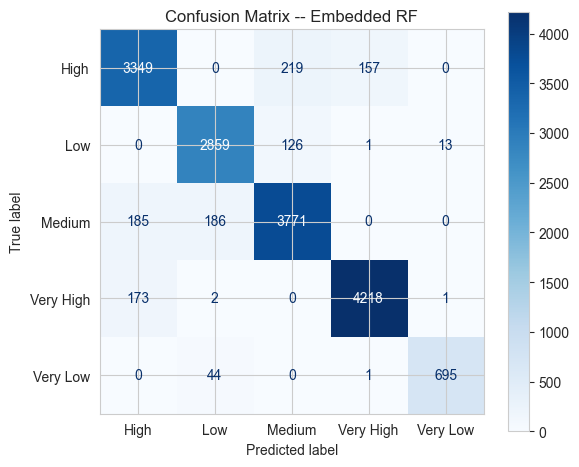


Model: Embedded XGBoost
Akurasi: 0.9334
              precision    recall  f1-score   support

        High       0.91      0.91      0.91      3725
         Low       0.92      0.95      0.94      2999
      Medium       0.92      0.91      0.91      4142
   Very High       0.97      0.96      0.97      4394
    Very Low       0.98      0.95      0.96       740

    accuracy                           0.93     16000
   macro avg       0.94      0.94      0.94     16000
weighted avg       0.93      0.93      0.93     16000



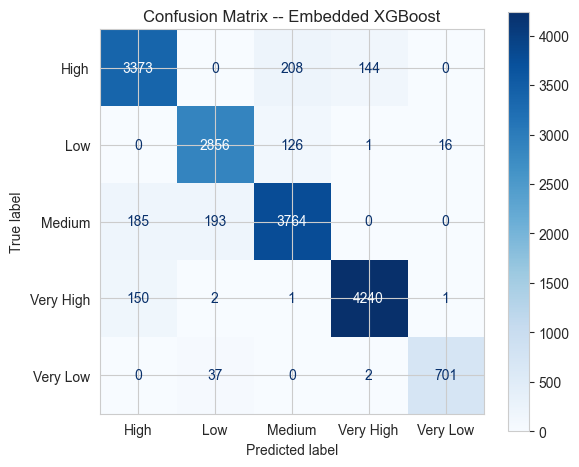

In [15]:
# Pilih top 8 fitur berdasarkan rata-rata importance
K_emb = 8
top_embedded = imp_df.head(K_emb)['Fitur'].tolist()
print(f"Top {K_emb} fitur (Embedded): {top_embedded}")

idx_emb = [feature_names.index(f) for f in top_embedded]
X_train_emb = X_train_sc[:, idx_emb]
X_test_emb = X_test_sc[:, idx_emb]

acc_rf_e, _ = evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                              X_train_emb, X_test_emb, y_train, y_test,
                              'Embedded RF', class_names)
results['Embedded RF'] = acc_rf_e

acc_xgb_e, _ = evaluate_model(XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False,
                                             eval_metric='mlogloss', verbosity=0),
                               X_train_emb, X_test_emb, y_train, y_test,
                               'Embedded XGBoost', class_names)
results['Embedded XGB'] = acc_xgb_e

**Analisis Embedded Method:**
- Feature importance dihitung selama proses training model.
- Random Forest mengukur importance berdasarkan penurunan impurity (Gini) saat split.
- XGBoost mengukur berdasarkan frekuensi fitur digunakan dalam split (gain).
- Fitur yang penting secara domain (Voltage, Temperature, Power) konsisten muncul
  di kedua model, menunjukkan bahwa hasil feature importance masuk akal secara fisika baterai.

---
## 6. Skenario 5 -- PCA (Principal Component Analysis)

In [16]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train_sc)

evr = pca_full.explained_variance_ratio_
cumulative = np.cumsum(evr)

print("Explained Variance Ratio per Komponen:")
for i, (ev, cum) in enumerate(zip(evr, cumulative)):
    print(f"  PC{i+1:>2}: {ev:.4f} (kumulatif: {cum:.4f})")

Explained Variance Ratio per Komponen:
  PC 1: 0.2769 (kumulatif: 0.2769)
  PC 2: 0.1703 (kumulatif: 0.4472)
  PC 3: 0.1431 (kumulatif: 0.5903)
  PC 4: 0.1350 (kumulatif: 0.7252)
  PC 5: 0.1060 (kumulatif: 0.8313)
  PC 6: 0.0768 (kumulatif: 0.9081)
  PC 7: 0.0545 (kumulatif: 0.9626)
  PC 8: 0.0203 (kumulatif: 0.9829)
  PC 9: 0.0133 (kumulatif: 0.9962)
  PC10: 0.0031 (kumulatif: 0.9993)
  PC11: 0.0004 (kumulatif: 0.9996)
  PC12: 0.0003 (kumulatif: 0.9999)
  PC13: 0.0001 (kumulatif: 1.0000)


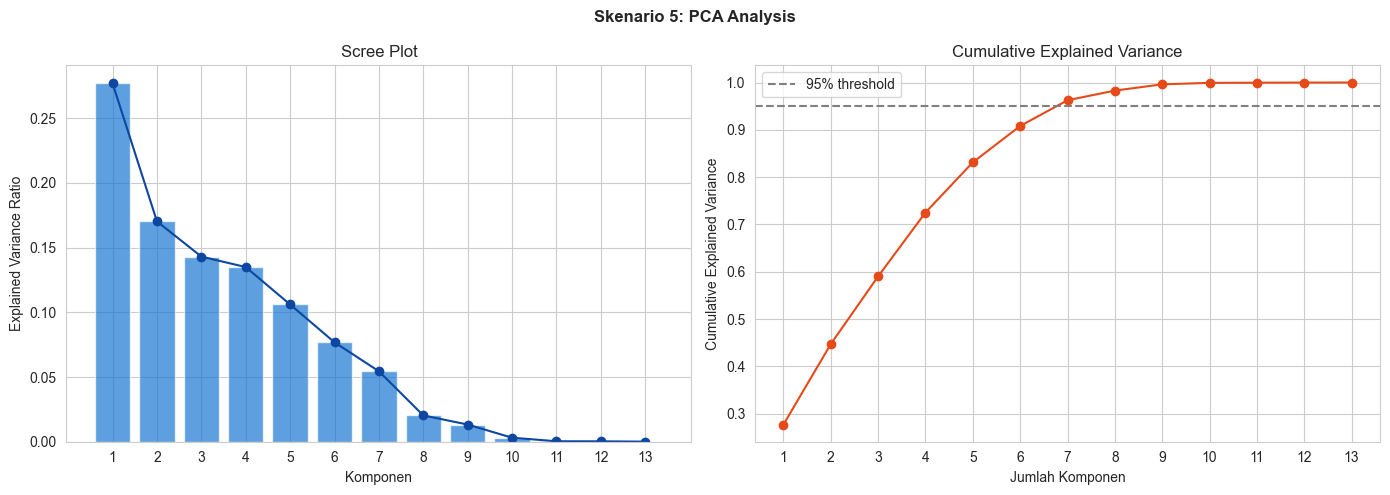

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(evr)+1), evr, color='#1976D2', alpha=0.7)
axes[0].plot(range(1, len(evr)+1), evr, 'o-', color='#0D47A1')
axes[0].set_xlabel('Komponen')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, len(evr)+1))

axes[1].plot(range(1, len(cumulative)+1), cumulative, 'o-', color='#E64A19')
axes[1].axhline(y=0.95, color='gray', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Jumlah Komponen')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(range(1, len(cumulative)+1))
axes[1].legend()

plt.suptitle('Skenario 5: PCA Analysis', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'images/week45', 'fig_pca_scree.png'), dpi=150, bbox_inches='tight')
plt.show()

Jumlah komponen untuk 95% varians: 7


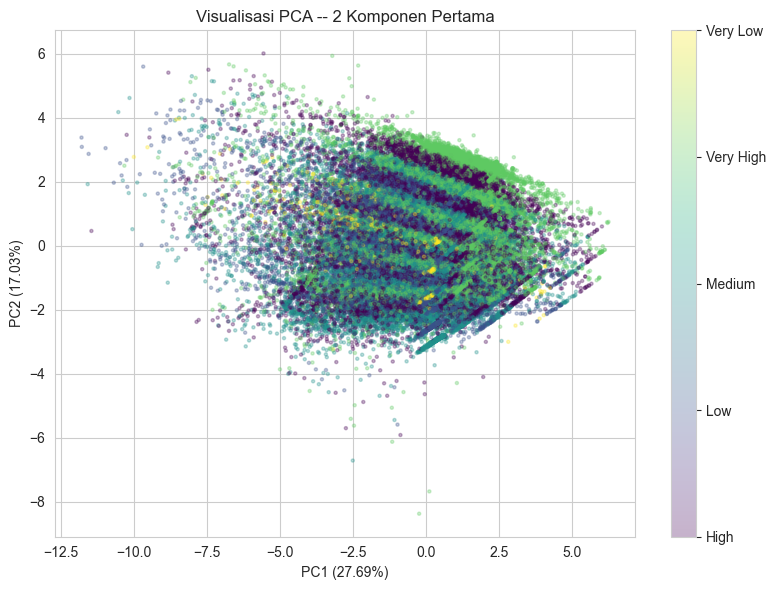

In [18]:
# Tentukan jumlah komponen yang menjelaskan >= 95% varians
n_components_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Jumlah komponen untuk 95% varians: {n_components_95}")

pca = PCA(n_components=n_components_95, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca = pca.transform(X_test_sc)

# Visualisasi PCA (2 komponen pertama)
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis',
                     alpha=0.3, s=5)
ax.set_xlabel(f'PC1 ({evr[0]:.2%})')
ax.set_ylabel(f'PC2 ({evr[1]:.2%})')
ax.set_title('Visualisasi PCA -- 2 Komponen Pertama')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_ticks(range(len(class_names)))
cbar.set_ticklabels(class_names)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'images/week45', 'fig_pca_visual.png'), dpi=150, bbox_inches='tight')
plt.show()


Model: PCA RF
Akurasi: 0.9062
              precision    recall  f1-score   support

        High       0.88      0.87      0.87      3725
         Low       0.90      0.92      0.91      2999
      Medium       0.88      0.89      0.88      4142
   Very High       0.95      0.95      0.95      4394
    Very Low       0.97      0.89      0.93       740

    accuracy                           0.91     16000
   macro avg       0.92      0.90      0.91     16000
weighted avg       0.91      0.91      0.91     16000



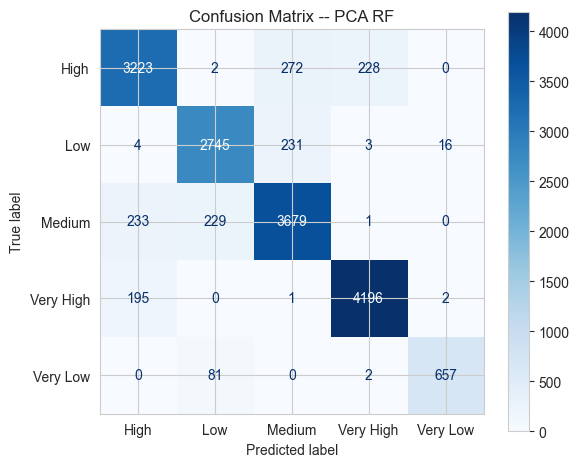


Model: PCA XGBoost
Akurasi: 0.9031
              precision    recall  f1-score   support

        High       0.87      0.86      0.87      3725
         Low       0.90      0.91      0.91      2999
      Medium       0.87      0.88      0.88      4142
   Very High       0.95      0.95      0.95      4394
    Very Low       0.97      0.91      0.94       740

    accuracy                           0.90     16000
   macro avg       0.91      0.90      0.91     16000
weighted avg       0.90      0.90      0.90     16000



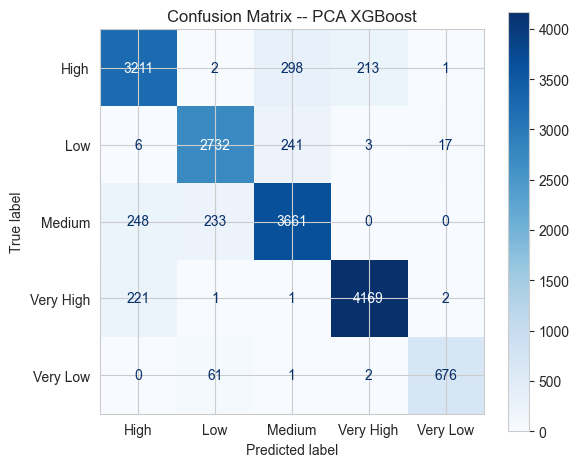

In [19]:
acc_rf_pca, _ = evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                                X_train_pca, X_test_pca, y_train, y_test,
                                'PCA RF', class_names)
results['PCA RF'] = acc_rf_pca

acc_xgb_pca, _ = evaluate_model(XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False,
                                               eval_metric='mlogloss', verbosity=0),
                                 X_train_pca, X_test_pca, y_train, y_test,
                                 'PCA XGBoost', class_names)
results['PCA XGB'] = acc_xgb_pca

---
## 7. Skenario 6 -- LDA (Linear Discriminant Analysis)

In [20]:
n_lda = min(len(class_names) - 1, len(feature_names))  # max = n_classes - 1
lda = LinearDiscriminantAnalysis(n_components=n_lda)
X_train_lda = lda.fit_transform(X_train_sc, y_train)
X_test_lda = lda.transform(X_test_sc)

print(f"Jumlah komponen LDA: {n_lda}")
print(f"Explained variance ratio: {lda.explained_variance_ratio_.round(4)}")

Jumlah komponen LDA: 4
Explained variance ratio: [9.662e-01 3.090e-02 2.300e-03 6.000e-04]


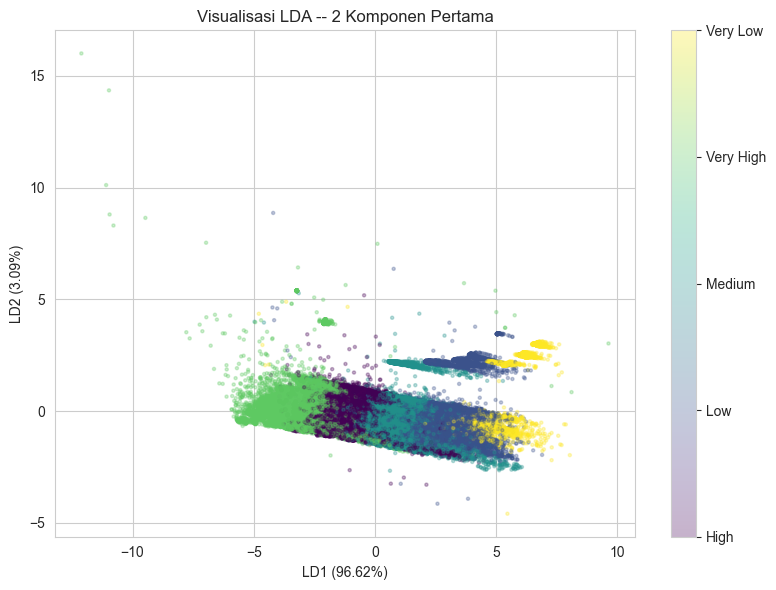

In [21]:
# Visualisasi LDA
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_train_lda[:, 0], X_train_lda[:, 1], c=y_train, cmap='viridis',
                     alpha=0.3, s=5)
ax.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]:.2%})')
ax.set_title('Visualisasi LDA -- 2 Komponen Pertama')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_ticks(range(len(class_names)))
cbar.set_ticklabels(class_names)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'images/week45', 'fig_lda_visual.png'), dpi=150, bbox_inches='tight')
plt.show()


Model: LDA RF
Akurasi: 0.8896
              precision    recall  f1-score   support

        High       0.85      0.84      0.85      3725
         Low       0.89      0.91      0.90      2999
      Medium       0.86      0.87      0.87      4142
   Very High       0.94      0.93      0.94      4394
    Very Low       0.96      0.91      0.94       740

    accuracy                           0.89     16000
   macro avg       0.90      0.89      0.90     16000
weighted avg       0.89      0.89      0.89     16000



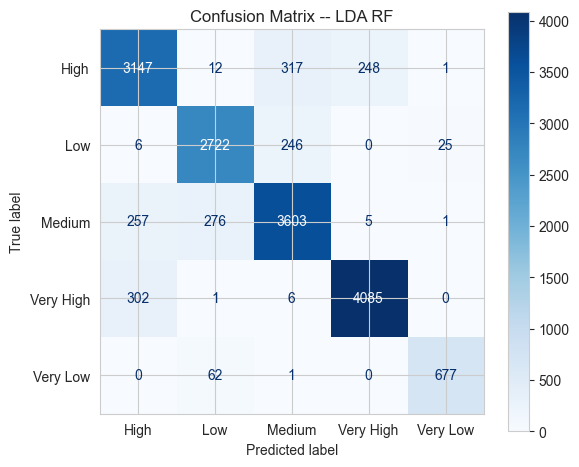


Model: LDA XGBoost
Akurasi: 0.8835
              precision    recall  f1-score   support

        High       0.84      0.83      0.83      3725
         Low       0.88      0.91      0.90      2999
      Medium       0.86      0.86      0.86      4142
   Very High       0.93      0.92      0.93      4394
    Very Low       0.96      0.92      0.94       740

    accuracy                           0.88     16000
   macro avg       0.89      0.89      0.89     16000
weighted avg       0.88      0.88      0.88     16000



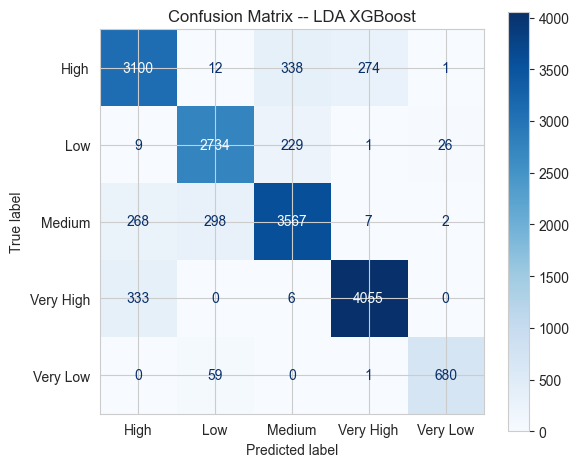

In [22]:
acc_rf_lda, _ = evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                                X_train_lda, X_test_lda, y_train, y_test,
                                'LDA RF', class_names)
results['LDA RF'] = acc_rf_lda

acc_xgb_lda, _ = evaluate_model(XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False,
                                               eval_metric='mlogloss', verbosity=0),
                                 X_train_lda, X_test_lda, y_train, y_test,
                                 'LDA XGBoost', class_names)
results['LDA XGB'] = acc_xgb_lda

### Komparasi PCA vs LDA

PCA dan LDA sama-sama mereduksi dimensi, namun dengan pendekatan berbeda:
- **PCA** bersifat unsupervised -- memaksimalkan varians data tanpa melihat label kelas.
- **LDA** bersifat supervised -- memaksimalkan separasi antar kelas.

Untuk klasifikasi SOC baterai kendaraan listrik:
- LDA diharapkan lebih efektif karena secara eksplisit mengoptimalkan pemisahan antar level SOC.
- PCA mempertahankan struktur umum data, yang mungkin termasuk varians noise.

---
## 8. Perbandingan Seluruh Skenario

In [23]:
print("\n" + "=" * 55)
print("PERBANDINGAN AKURASI SELURUH SKENARIO")
print("=" * 55)

res_df = pd.DataFrame([
    {'Skenario': 'S1 Baseline', 'Model': 'Random Forest', 'Akurasi': results.get('Baseline RF', 0)},
    {'Skenario': 'S1 Baseline', 'Model': 'XGBoost', 'Akurasi': results.get('Baseline XGB', 0)},
    {'Skenario': 'S2 Filter', 'Model': 'Random Forest', 'Akurasi': results.get('Filter RF', 0)},
    {'Skenario': 'S2 Filter', 'Model': 'XGBoost', 'Akurasi': results.get('Filter XGB', 0)},
    {'Skenario': 'S3 Wrapper', 'Model': 'Random Forest', 'Akurasi': results.get('Wrapper RF', 0)},
    {'Skenario': 'S3 Wrapper', 'Model': 'XGBoost', 'Akurasi': results.get('Wrapper XGB', 0)},
    {'Skenario': 'S4 Embedded', 'Model': 'Random Forest', 'Akurasi': results.get('Embedded RF', 0)},
    {'Skenario': 'S4 Embedded', 'Model': 'XGBoost', 'Akurasi': results.get('Embedded XGB', 0)},
    {'Skenario': 'S5 PCA', 'Model': 'Random Forest', 'Akurasi': results.get('PCA RF', 0)},
    {'Skenario': 'S5 PCA', 'Model': 'XGBoost', 'Akurasi': results.get('PCA XGB', 0)},
    {'Skenario': 'S6 LDA', 'Model': 'Random Forest', 'Akurasi': results.get('LDA RF', 0)},
    {'Skenario': 'S6 LDA', 'Model': 'XGBoost', 'Akurasi': results.get('LDA XGB', 0)},
])
res_df['Akurasi'] = res_df['Akurasi'].round(4)
print(res_df.to_string(index=False))


PERBANDINGAN AKURASI SELURUH SKENARIO
   Skenario         Model  Akurasi
S1 Baseline Random Forest   0.9319
S1 Baseline       XGBoost   0.9382
  S2 Filter Random Forest   0.9269
  S2 Filter       XGBoost   0.9334
 S3 Wrapper Random Forest   0.9316
 S3 Wrapper       XGBoost   0.9328
S4 Embedded Random Forest   0.9308
S4 Embedded       XGBoost   0.9334
     S5 PCA Random Forest   0.9062
     S5 PCA       XGBoost   0.9031
     S6 LDA Random Forest   0.8896
     S6 LDA       XGBoost   0.8835


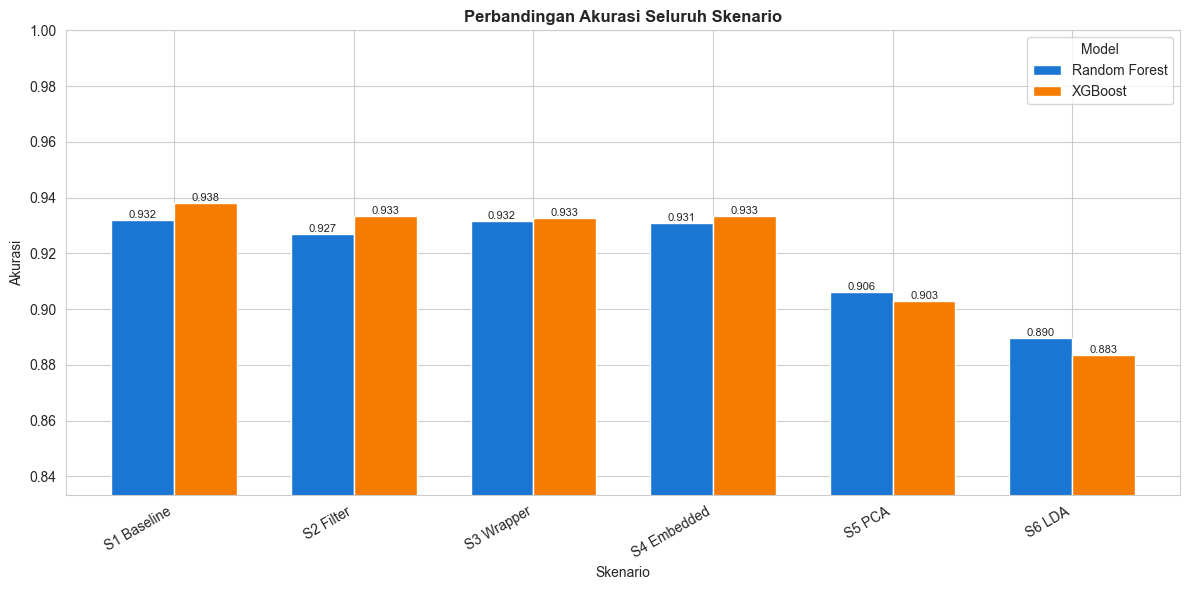

In [24]:
# Visualisasi perbandingan
fig, ax = plt.subplots(figsize=(12, 6))
pivot = res_df.pivot(index='Skenario', columns='Model', values='Akurasi')
pivot = pivot.loc[['S1 Baseline','S2 Filter','S3 Wrapper','S4 Embedded','S5 PCA','S6 LDA']]
pivot.plot(kind='bar', ax=ax, color=['#1976D2', '#F57C00'], edgecolor='white', width=0.7)
ax.set_ylabel('Akurasi')
ax.set_title('Perbandingan Akurasi Seluruh Skenario', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_ylim(max(0, res_df['Akurasi'].min() - 0.05), 1.0)
ax.legend(title='Model')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'images/week45', 'fig_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Kesimpulan

### Kondisi Awal Dataset
Dataset berasal dari pengujian baterai LG 18650HG2 untuk kendaraan listrik kompak.
Setelah feature engineering, diperoleh 13 fitur numerik (Capacity dan WhAccu di-exclude
untuk menghindari data leakage). SOC kontinu di-binning menjadi 5 kelas untuk task klasifikasi.

### Ringkasan Fitur Terpilih

| Metode | Pendekatan | Jumlah Fitur | Catatan |
|---|---|---|---|
| Filter (MI + ANOVA) | Statistik univariat | 8 | Cepat, tidak lihat interaksi |
| Wrapper (RFE) | Iteratif berbasis model | 8 | Lihat interaksi, komputasi berat |
| Embedded (RF + XGB) | Saat training | 8 | Efisien, terintegrasi dgn model |
| PCA | Reduksi unsupervised | N komponen (95% var) | Transformasi, tidak interpretable |
| LDA | Reduksi supervised | 4 (n_class - 1) | Separasi kelas optimal |

### Analisis Performa
- Feature selection (Filter/Wrapper/Embedded) umumnya mempertahankan atau sedikit menurunkan
  akurasi dibanding baseline, karena fitur yang dihapus memang kurang informatif.
- PCA mereduksi dimensi secara signifikan namun kehilangan interpretabilitas.
- LDA memberikan separasi kelas yang lebih jelas karena bersifat supervised.
- Metode yang paling efektif dipilih berdasarkan trade-off antara akurasi dan jumlah fitur.